In [23]:
import re
import os
import nltk
import string
from nltk.corpus import stopwords

import numpy as np
import pandas as pd

from keras.models import Model
from keras.utils import pad_sequences
from keras.preprocessing.text import Tokenizer
from keras.layers import Conv1D, MaxPooling1D, Embedding, Concatenate, Dense, Input, Flatten

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [16]:
Max_sequence_length = 100
Embedding_dim = 100

In [3]:
data = pd.read_csv('ISEAR_Dataset.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7516 entries, 0 to 7515
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sentiment   7516 non-null   object
 1   content     7516 non-null   object
 2   Unnamed: 2  3 non-null      object
dtypes: object(3)
memory usage: 176.3+ KB


In [5]:
def actual_tag(string):
    if string.startswith('J'):
        return nltk.corpus.wordnet.ADJ
    elif string.startswith('V'):
        return nltk.corpus.wordnet.VERB
    elif string.startswith('N'):
        return nltk.corpus.wordnet.NOUN
    elif string.startswith('R'):
        return nltk.corpus.wordnet.ADV
    else:
        return nltk.corpus.wordnet.NOUN

In [6]:
def lemmatize(array):
    opt_list = []
    wl = nltk.WordNetLemmatizer()
    stop = stopwords.words('english')
    stop += list(string.punctuation)
    for tple in array:
        word, tag = tple
        if word.lower() not in stop and word.isalpha():
            temp = wl.lemmatize(word,actual_tag(tag))
            opt_list.append(temp.lower())
    return opt_list

In [7]:
def preprocess(text):
    text = nltk.tokenize.word_tokenize(text)
    text = nltk.pos_tag(text)
    text = lemmatize(text)
    return text

In [10]:
processed_data = data['content'].map(preprocess)

In [11]:
processed_data.head()

0    [day, feel, close, partner, friend, feel, peac...
1    [every, time, imagine, someone, love, could, c...
2    [obviously, unjustly, treat, possibility, eluc...
3    [think, short, time, live, relate, period, lif...
4    [gathering, find, involuntarily, sit, next, tw...
Name: content, dtype: object

In [12]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(processed_data)
sequences = tokenizer.texts_to_sequences(processed_data)

word_index = tokenizer.word_index
len(word_index)

7020

In [13]:
features = pad_sequences(sequences, Max_sequence_lengh)
labels = pd.get_dummies(data['sentiment'])
features.shape, labels.shape

((7516, 100), (7516, 7))

In [14]:
labels.head()

,anger,disgust,fear,guilt,joy,sadness,shame
0,0,0,0,0,1,0,0
1,0,0,1,0,0,0,0
2,1,0,0,0,0,0,0
3,0,0,0,0,0,1,0
4,0,1,0,0,0,0,0


In [15]:
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size = 0.2, random_state = 20)
x_test, x_val, y_test, y_val = train_test_split( features, labels, test_size=0.50, random_state=4)
x_train.shape, x_test.shape, x_val.shape, y_train.shape, y_test.shape, y_val.shape

((6012, 100), (3758, 100), (3758, 100), (6012, 7), (3758, 7), (3758, 7))

In [17]:
embedding_index = {}
with open(r"D:\Notebook\Projects\Embedding_Models\glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        value = line.split()
        word = value[0]
        vector = np.asarray(value[1:], dtype = 'float32')
        embedding_index[word] = vector
        
embedding_matrix = np.zeros((len(word_index)+1, Embedding_dim))

for word,i in word_index.items():
    embd_vector = embedding_index.get(word)
    if embd_vector is not None:
        embedding_matrix[i] = vector

        
embedding_layer = Embedding(len(word_index)+1,Embedding_dim, weights = [embedding_matrix],
                            input_length=Max_sequence_length)

In [18]:
convs = []
filter_sizes = [3,4,5]

sequence_input = Input(shape=(Max_sequence_length,))
embedded_sequences = embedding_layer(sequence_input)

for fsz in filter_sizes:
    l_conv = Conv1D(128,fsz,activation='relu')(embedded_sequences)
    l_pool = MaxPooling1D(5)(l_conv)
    convs.append(l_pool)   
l_merge = Concatenate()(convs)
l_cov1= Conv1D(filters=128, kernel_size=5, activation='relu')(l_merge)
l_pool1 = MaxPooling1D(5)(l_cov1)
# l_cov2 = Conv1D(filters=128, kernel_size=5, activation='relu')(l_pool1)
# l_pool2 = MaxPooling1D(30)(l_cov2)
l_flat = Flatten()(l_pool1)
l_dense = Dense(128, activation='relu')(l_flat)
preds = Dense(7, activation='softmax')(l_dense)

model = Model(sequence_input, preds)
model.compile(loss='binary_crossentropy',
              optimizer='Nadam',
              metrics=['acc'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 100)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 100, 100)             702100    ['input_1[0][0]']             
                                                                                                  
 conv1d (Conv1D)             (None, 98, 128)              38528     ['embedding[0][0]']           
                                                                                                  
 conv1d_1 (Conv1D)           (None, 97, 128)              51328     ['embedding[0][0]']           
                                                                                              

In [19]:
history = model.fit(x_train,y_train , validation_data=(x_val,y_val), epochs=25, batch_size=150, verbose=1)

Epoch 1/25
41/41 [==============================] - 9s 165ms/step - loss: 0.4487 - acc: 0.1452 - val_loss: 0.4139 - val_acc: 0.1629
Epoch 2/25
41/41 [==============================] - 6s 150ms/step - loss: 0.4094 - acc: 0.1630 - val_loss: 0.4075 - val_acc: 0.1924
Epoch 3/25
41/41 [==============================] - 6s 146ms/step - loss: 0.4073 - acc: 0.1850 - val_loss: 0.4074 - val_acc: 0.2070
Epoch 4/25
41/41 [==============================] - 6s 144ms/step - loss: 0.3967 - acc: 0.2244 - val_loss: 0.3804 - val_acc: 0.2384
Epoch 5/25
41/41 [==============================] - 6s 150ms/step - loss: 0.3615 - acc: 0.3305 - val_loss: 0.3396 - val_acc: 0.4287
Epoch 6/25
41/41 [==============================] - 6s 147ms/step - loss: 0.3169 - acc: 0.4732 - val_loss: 0.3020 - val_acc: 0.5232
Epoch 7/25
41/41 [==============================] - 6s 159ms/step - loss: 0.2674 - acc: 0.5848 - val_loss: 0.3435 - val_acc: 0.4633
Epoch 8/25
41/41 [==============================] - 7s 167ms/step - loss: 0.

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


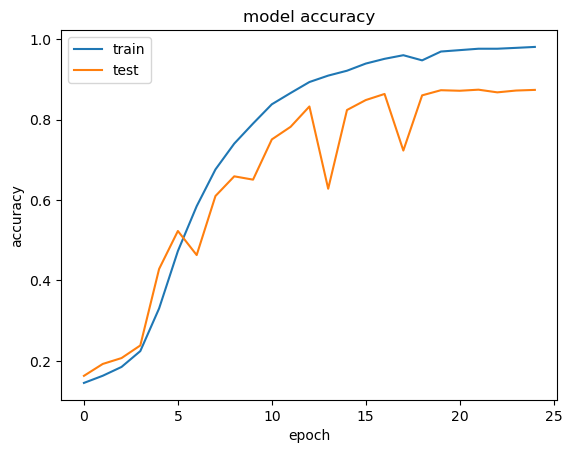

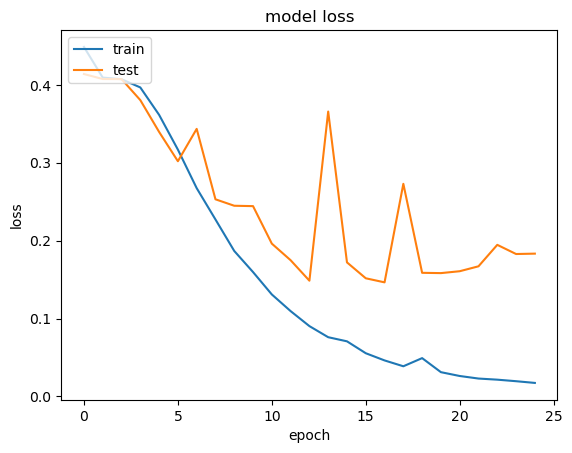

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline 
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [25]:
y_pred = model.predict(x_test, verbose=1)

118/118 [==============================] - 1s 8ms/step


In [26]:
arr = np.argmax(np.asarray(y_test), axis=1)
ans = np.argmax(y_pred, axis=1)
f1 = f1_score(arr,ans, average='micro')
r1 = recall_score(arr, ans, average='micro')
p1 = precision_score(arr,ans, average='micro')
acc = accuracy_score(arr,ans)
print('f1',f1)
print('r1',r1)
print('p1',p1)
print('acc',acc)

f1 0.8799893560404471
r1 0.879989356040447
p1 0.879989356040447
acc 0.879989356040447


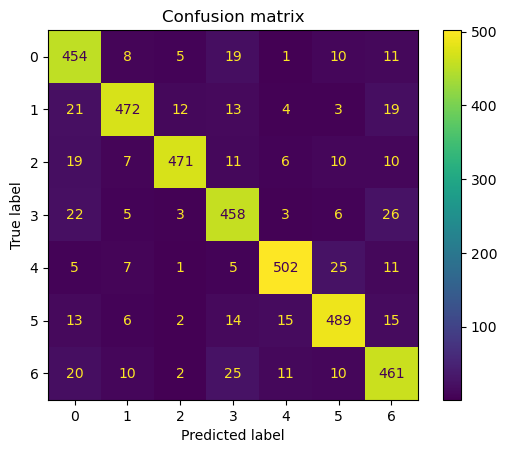

In [27]:
cm = confusion_matrix(arr, ans)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(set(arr)))
disp.plot()
plt.title("Confusion matrix")
plt.show()